In [12]:
!pip install -q -r ../../requirements-dev.txt
!pip install -q -r ../../requirements-avito.txt
!pip install -q -r ../../requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../../requirements-dev.txt'

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../../requirements-avito.txt'

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../../requirements.txt'


In [9]:
from common.paths import *
from avito.embeddings import *

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

[WinError 2] Не удается найти указанный файл: 'ditriy'
c:\Users\ditriy\Desktop


C:\Users\ditriy\AppData\Roaming\Python\Python311\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


ModuleNotFoundError: No module named 'common'

Что внутри:

3000 объявлений
11 микрокатегорий из исходного справочника
кейсы разных типов:
single_direct
turnkey_no_split
turnkey_split
multi_service_split
multi_service_no_split
bullets_mixed
noisy_short
Колонки:


itemId: идентификатор объявления

sourceMcId: исходная микрокатегория объявления

sourceMcTitle: название исходной микрокатегории

description: текст объявления

targetDetectedMcIds: список всех найденных mcId в тексте

targetSplitMcIds: список mcId, по которым стоит создать дополнительные draft

shouldSplit: есть ли хотя бы один дополнительный draft

caseType: тип сценария

split: train / val / test


Статистика:

всего записей: 3000

доля shouldSplit=true: 0.371

train/val/test: {'train': 2094, 'test': 459, 'val': 447}

распределение кейсов: {'single_direct': 843, 'turnkey_no_split': 544, 'turnkey_split': 535, 'bullets_mixed': 307, 'multi_service_no_split': 294, 'multi_service_split': 252, 'noisy_short': 225}

In [2]:
data_fpath = get_avito_data_dpath() / "rnc_dataset.csv"
df = pd.read_csv(data_fpath)
df.head()

,itemId,sourceMcId,sourceMcTitle,description,targetDetectedMcIds,targetSplitMcIds,shouldSplit,caseType,split
0,1,108,Штукатурные работы,штукатурка под обои в офис. Делаю ремонт штука...,[108],[],False,single_direct,train
1,2,101,Ремонт квартир и домов под ключ,Косметический ремонт под ключ в доме. Отдельно...,"[101, 111, 108, 110, 104]","[111, 108, 110, 104]",True,turnkey_split,test
2,3,109,Напольные покрытия,напольные покрытия /монтаж перегородок выезд з...,"[109, 110]",[],False,noisy_short,val
3,4,102,Сантехника,Монтаж сантехники в коттедж. Делаю монтаж бойл...,[102],[],False,single_direct,train
4,5,101,Ремонт квартир и домов под ключ,"Комплекс работ по ремонту во вторичке. гкл, гк...","[101, 110, 111]",[],False,turnkey_no_split,train


In [3]:
id_title = df[["sourceMcId", "sourceMcTitle"]].drop_duplicates().set_index("sourceMcId")["sourceMcTitle"].to_dict()

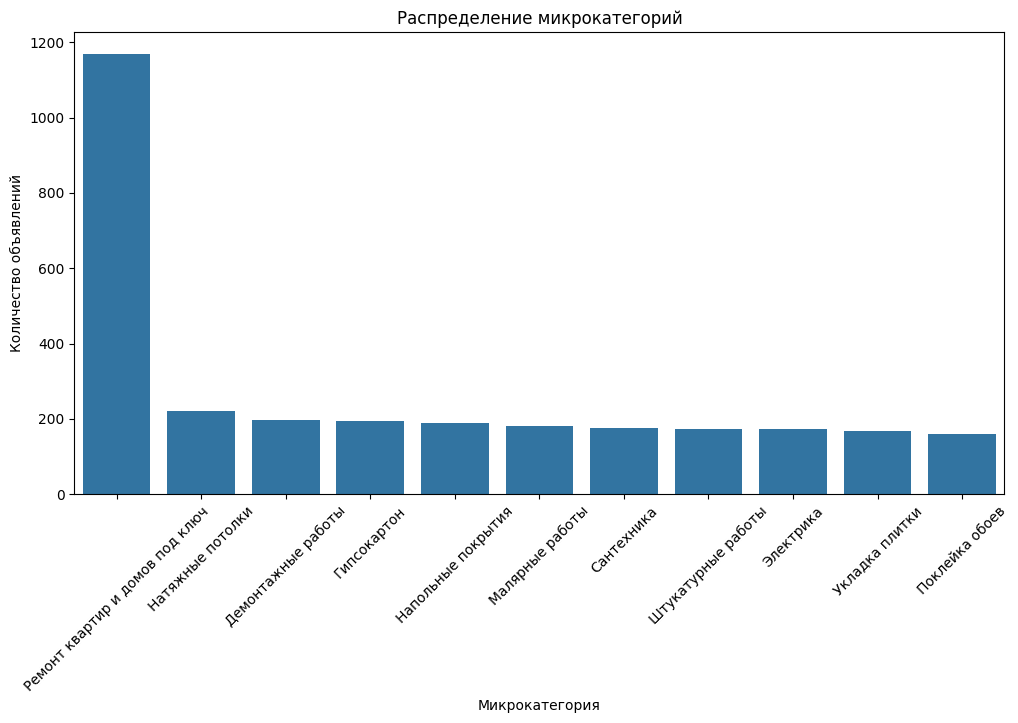

In [4]:
mc_title_dist = df["sourceMcTitle"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=mc_title_dist.index, y=mc_title_dist.values)
plt.xticks(rotation=45)
plt.title("Распределение микрокатегорий")
plt.xlabel("Микрокатегория")
plt.ylabel("Количество объявлений")
plt.show()

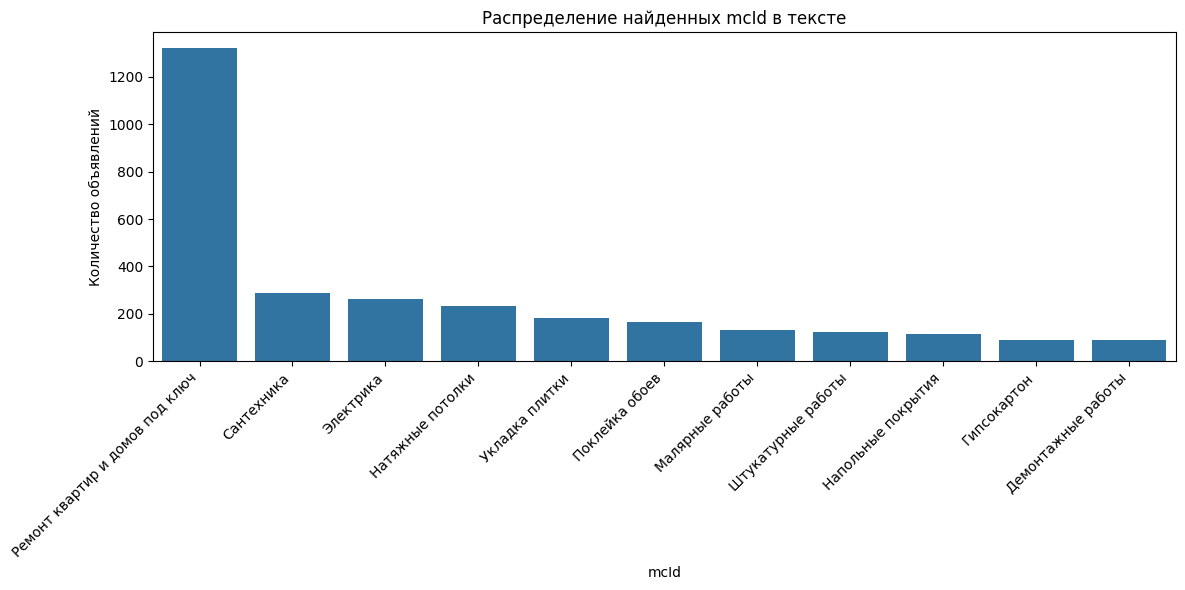

In [5]:
from collections import Counter

united_target_mc_ids = df["targetDetectedMcIds"].apply(
    lambda x: id_title[int(x.strip("[]").split(",")[0])] if x.strip("[]") else None
).dropna().tolist()

target_mc_id_dist = Counter(united_target_mc_ids)
sorted_items = sorted(target_mc_id_dist.items(), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(12, 6))
sns.barplot(x=[k for k, _ in sorted_items], y=[v for _, v in sorted_items])
plt.xticks(rotation=45, ha="right")
plt.title("Распределение найденных mcId в тексте")
plt.xlabel("mcId")
plt.ylabel("Количество объявлений")
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_5648\3068685323.py:16: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  normalized_matrix = np.divide(cooccurrence_matrix, row_sums, where=row_sums != 0)


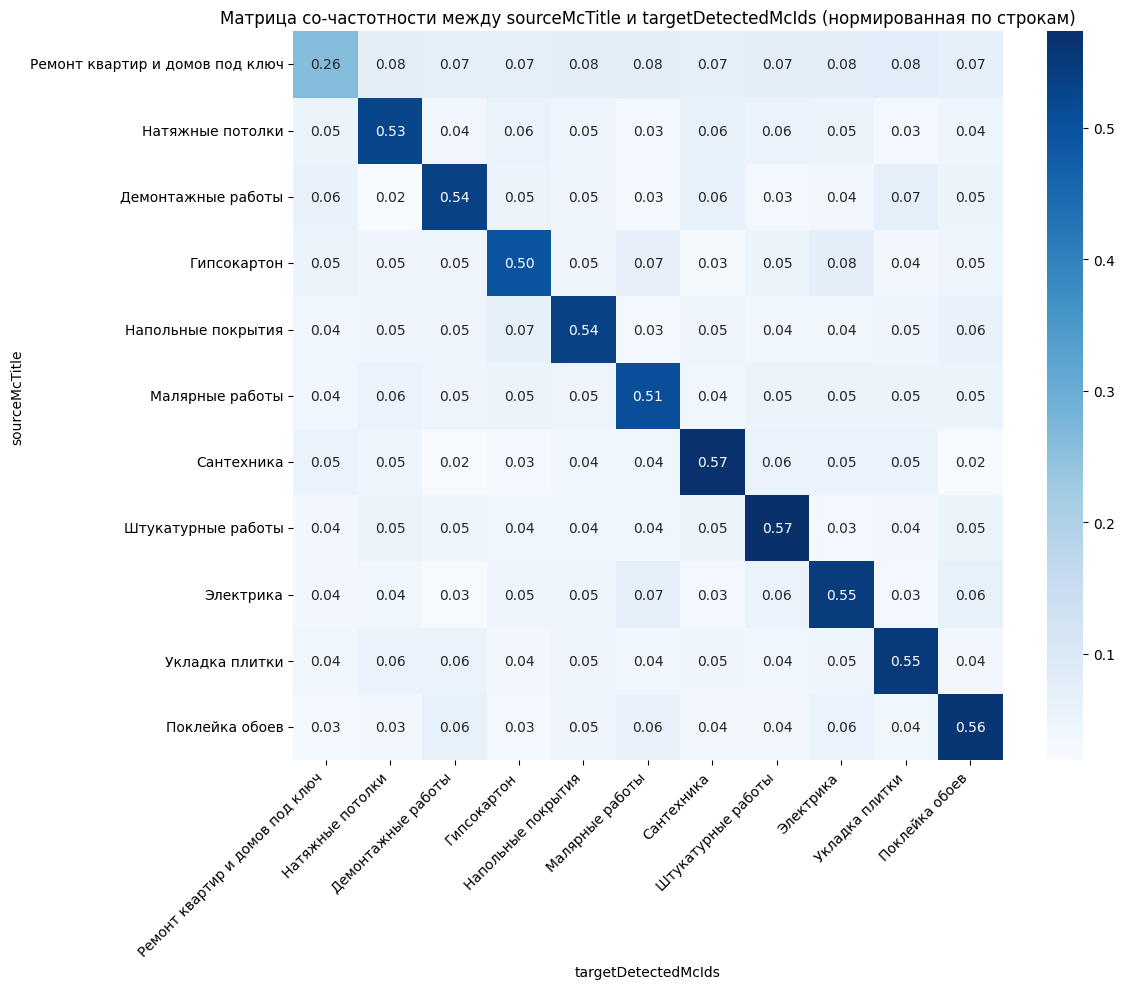

In [6]:
import numpy as np

cooccurrence_matrix = np.zeros((len(mc_title_dist), len(mc_title_dist)), dtype=int)
mc_title_to_index = {title: idx for idx, title in enumerate(mc_title_dist.index)}
for _, row in df.iterrows():
    source_idx = mc_title_to_index[row["sourceMcTitle"]]
    target_mc_ids = row["targetDetectedMcIds"].strip("[]").split(",") if row["targetDetectedMcIds"].strip("[]") else []
    for target_id in target_mc_ids:
        if target_id:
            target_title = id_title.get(int(target_id), None)
            if target_title and target_title in mc_title_to_index:
                target_idx = mc_title_to_index[target_title]
                cooccurrence_matrix[source_idx, target_idx] += 1

row_sums = cooccurrence_matrix.sum(axis=1, keepdims=True)
normalized_matrix = np.divide(cooccurrence_matrix, row_sums, where=row_sums != 0)

plt.figure(figsize=(12, 10))
sns.heatmap(normalized_matrix, xticklabels=mc_title_dist.index, yticklabels=mc_title_dist.index, cmap="Blues", annot=True, fmt=".2f")
plt.title("Матрица со-частотности между sourceMcTitle и targetDetectedMcIds (нормированная по строкам)")
plt.xlabel("targetDetectedMcIds")
plt.ylabel("sourceMcTitle")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
all_categories = sorted(set(df["sourceMcTitle"].unique()))

source_dist = df["sourceMcTitle"].value_counts()
target_dist = Counter(dict(sorted_items))

source_vec = np.array([source_dist.get(cat, 0) for cat in all_categories], dtype=float)
target_vec = np.array([target_dist.get(cat, 0) for cat in all_categories], dtype=float)

source_vec /= source_vec.sum()
target_vec /= target_vec.sum()

l2_distance = np.linalg.norm(source_vec - target_vec)
print(f"L2 расстояние между распределениями: {l2_distance:.4f}")

L2 расстояние между распределениями: 0.0922


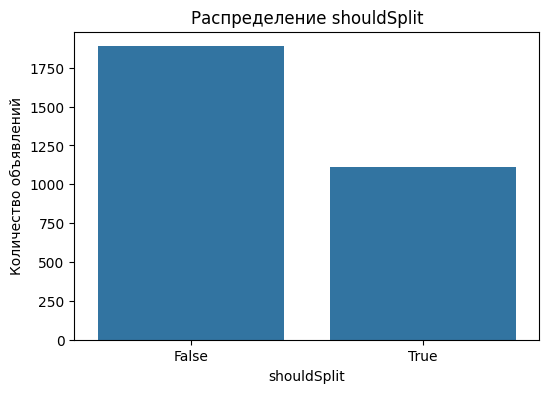

In [8]:
should_split_dist = df["shouldSplit"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=should_split_dist.index, y=should_split_dist.values)
plt.title("Распределение shouldSplit")
plt.xlabel("shouldSplit")
plt.ylabel("Количество объявлений")
plt.show()

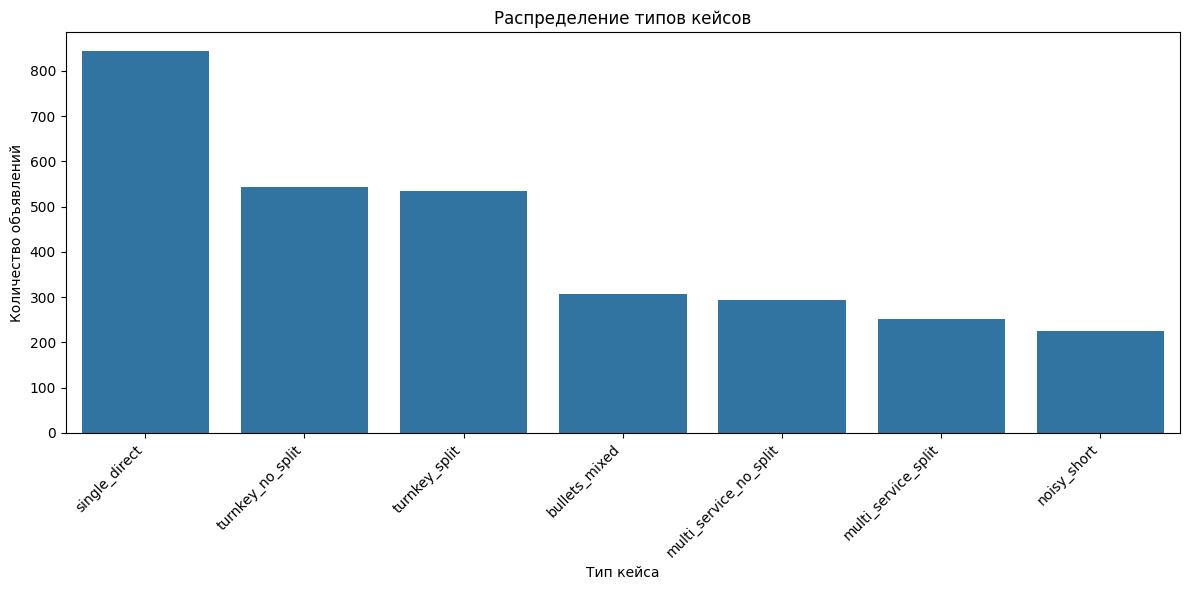

In [9]:
case_type_dist = df["caseType"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=case_type_dist.index, y=case_type_dist.values)
plt.xticks(rotation=45, ha="right")
plt.title("Распределение типов кейсов")
plt.xlabel("Тип кейса")
plt.ylabel("Количество объявлений")
plt.tight_layout()
plt.show()

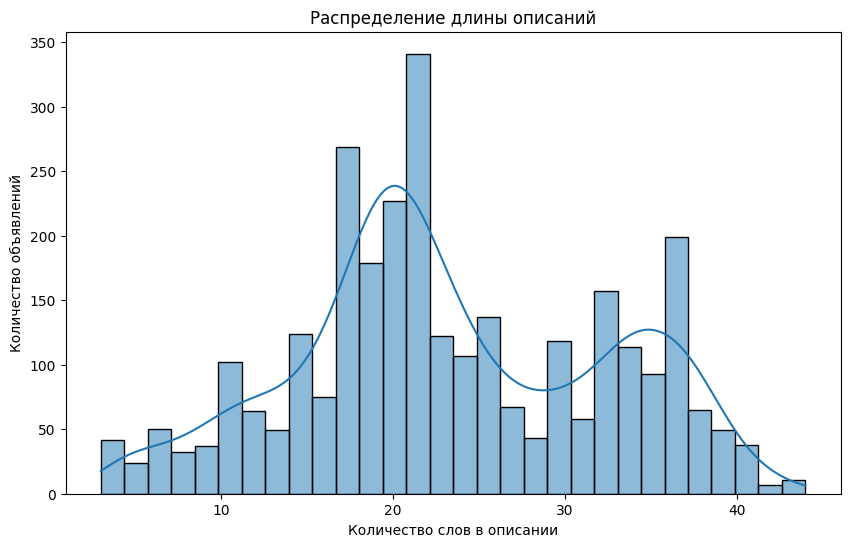

In [10]:
len_desc = df["description"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(len_desc, bins=30, kde=True)
plt.title("Распределение длины описаний")
plt.xlabel("Количество слов в описании")
plt.ylabel("Количество объявлений")
plt.show()

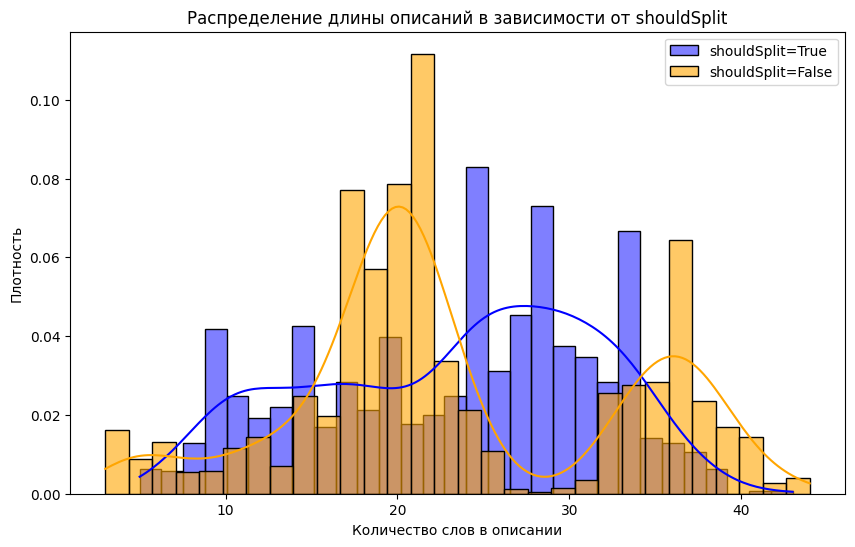

Средняя длина описания для shouldSplit=True: 23.36 слов
Средняя длина описания для shouldSplit=False: 23.32 слов


In [11]:
len_desc_vs_split = df.groupby("shouldSplit")["description"].apply(lambda x: x.apply(lambda desc: len(str(desc).split())))

plt.figure(figsize=(10, 6))
sns.histplot(len_desc_vs_split[True], bins=30, color="blue", label="shouldSplit=True", kde=True, stat="density")
sns.histplot(len_desc_vs_split[False], bins=30, color="orange", label="shouldSplit=False", kde=True, stat="density", alpha=0.6)
plt.title("Распределение длины описаний в зависимости от shouldSplit")
plt.xlabel("Количество слов в описании")
plt.ylabel("Плотность")
plt.legend()
plt.show()

print(f"Средняя длина описания для shouldSplit=True: {len_desc_vs_split[True].mean():.2f} слов")
print(f"Средняя длина описания для shouldSplit=False: {len_desc_vs_split[False].mean():.2f} слов")

In [12]:
!pip install -q nltk
import nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt")
# russian stopwords
nltk.download("stopwords")
stop_words = set(nltk.corpus.stopwords.words("russian"))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


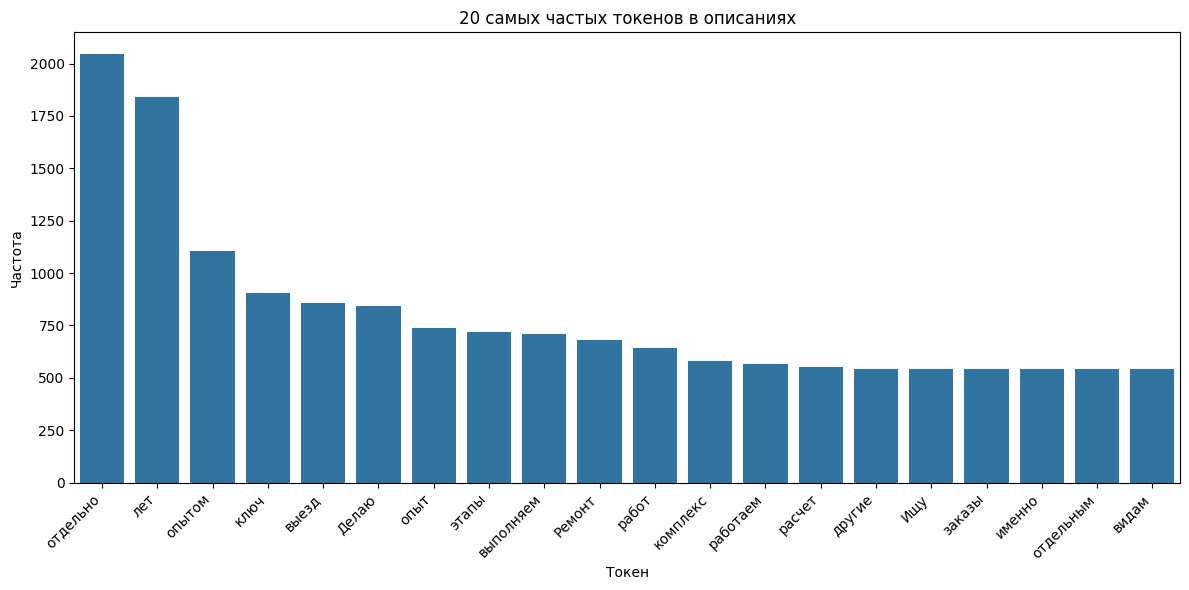

In [13]:
corpus = df["description"].dropna().tolist()
tokenized_corpus = [word_tokenize(desc) for desc in corpus]
all_tokens = [token for desc in tokenized_corpus for token in desc if token.isalpha() and token.lower() not in stop_words]
token_freq = Counter(all_tokens)
most_common_tokens = token_freq.most_common(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=[token for token, _ in most_common_tokens], y=[freq for _, freq in most_common_tokens])
plt.xticks(rotation=45, ha="right")
plt.title("20 самых частых токенов в описаниях")
plt.xlabel("Токен")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

## Embeddings

In [14]:
encoder = SentenceTransformerEncoder(EncoderConfig.from_default_yaml())

df["embedding"] = encoder.encode(df["description"].fillna("").tolist())
df.head()

2026-03-28 02:10:52,528 - avito-embeddings - INFO - [AVITO/EMBEDDINGS] Пробую загрузить локальную модель: C:\Users\User\Desktop\dirs\Dev\hack-mfti\checkpoints\rubert-mini-frida


Loading weights:   0%|          | 0/119 [00:00<?, ?it/s]

Default prompt name is set to 'Classification'. This prompt will be applied to all `encode()` calls, except if `encode()` is called with `prompt` or `prompt_name` parameters.
2026-03-28 02:10:52,965 - avito-embeddings - INFO - [AVITO/EMBEDDINGS] Запуск encode для 3000 текстов


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

,itemId,sourceMcId,sourceMcTitle,description,targetDetectedMcIds,targetSplitMcIds,shouldSplit,caseType,split,embedding
0,1,108,Штукатурные работы,штукатурка под обои в офис. Делаю ремонт штука...,[108],[],False,single_direct,train,"[-0.06789873540401459, 0.0139473220333457, -0...."
1,2,101,Ремонт квартир и домов под ключ,Косметический ремонт под ключ в доме. Отдельно...,"[101, 111, 108, 110, 104]","[111, 108, 110, 104]",True,turnkey_split,test,"[-0.0568474642932415, 0.038801711052656174, 0...."
2,3,109,Напольные покрытия,напольные покрытия /монтаж перегородок выезд з...,"[109, 110]",[],False,noisy_short,val,"[0.0012883845483884215, 0.060568660497665405, ..."
3,4,102,Сантехника,Монтаж сантехники в коттедж. Делаю монтаж бойл...,[102],[],False,single_direct,train,"[0.0026341972406953573, 0.1026536151766777, -0..."
4,5,101,Ремонт квартир и домов под ключ,"Комплекс работ по ремонту во вторичке. гкл, гк...","[101, 110, 111]",[],False,turnkey_no_split,train,"[-0.008561786264181137, 0.10312935709953308, 0..."


In [15]:
from umap import UMAP
from sklearn.metrics import silhouette_score

# парсим эмбеддинги
embeddings = np.array(df["embedding"].tolist())
labels_split = df["shouldSplit"].astype(int).values
labels_mc = df["sourceMcTitle"].values
labels_case = df["caseType"].values

# UMAP
reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
emb_2d = reducer.fit_transform(embeddings)
df["umap_x"] = emb_2d[:, 0]
df["umap_y"] = emb_2d[:, 1]

C:\Users\User\anaconda3\envs\hack-mfti\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


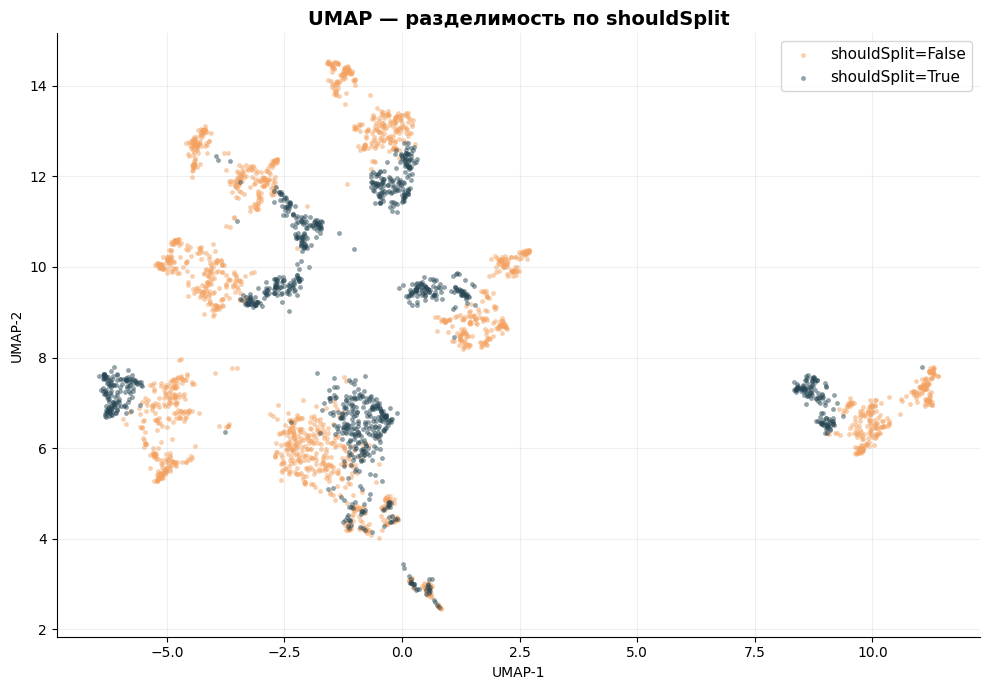

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = {0: "#f4a261", 1: "#264653"}
for val, label in [(0, "shouldSplit=False"), (1, "shouldSplit=True")]:
    mask = labels_split == val
    ax.scatter(df["umap_x"][mask], df["umap_y"][mask], c=colors[val],
               label=label, alpha=0.5, s=12, linewidths=0)
ax.set_title("UMAP — разделимость по shouldSplit", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.grid(True, alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

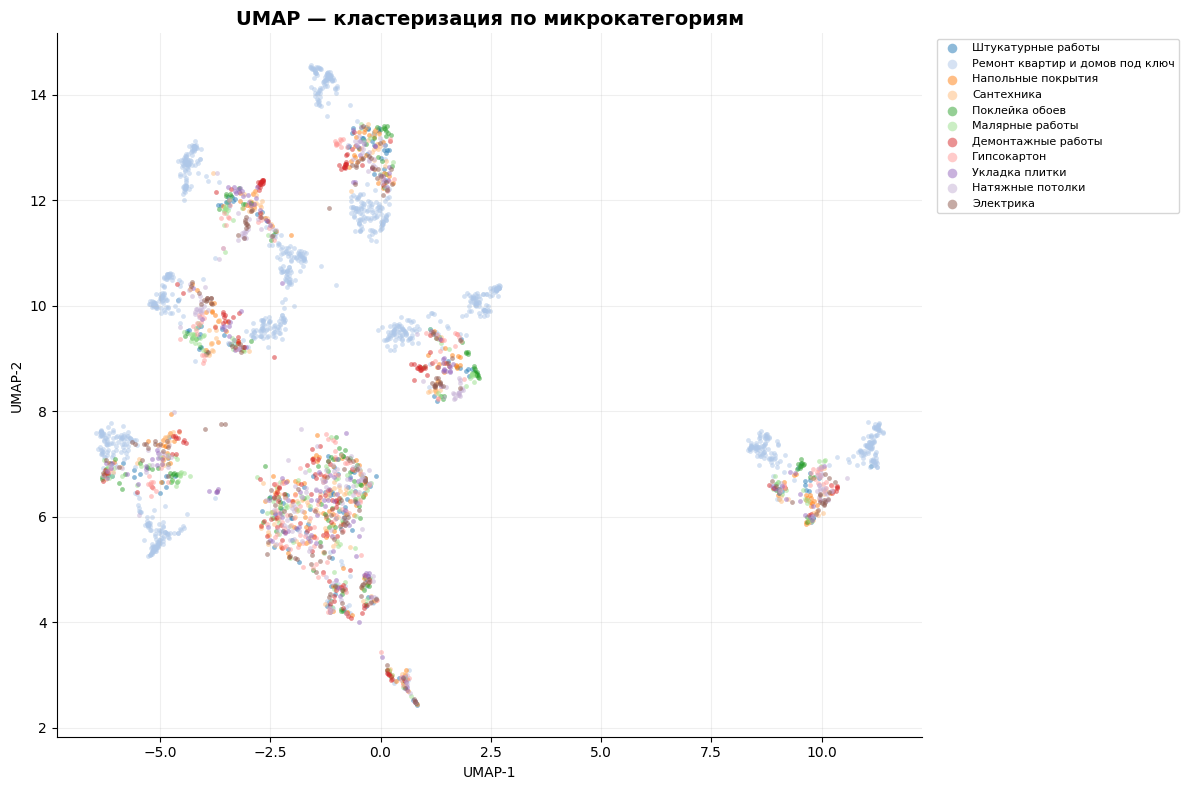

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))
mc_titles = df["sourceMcTitle"].unique()
palette = sns.color_palette("tab20", len(mc_titles))
for i, mc in enumerate(mc_titles):
    mask = df["sourceMcTitle"] == mc
    ax.scatter(df["umap_x"][mask], df["umap_y"][mask],
               c=[palette[i]], label=mc, alpha=0.5, s=12, linewidths=0)
ax.set_title("UMAP — кластеризация по микрокатегориям", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, markerscale=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.grid(True, alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

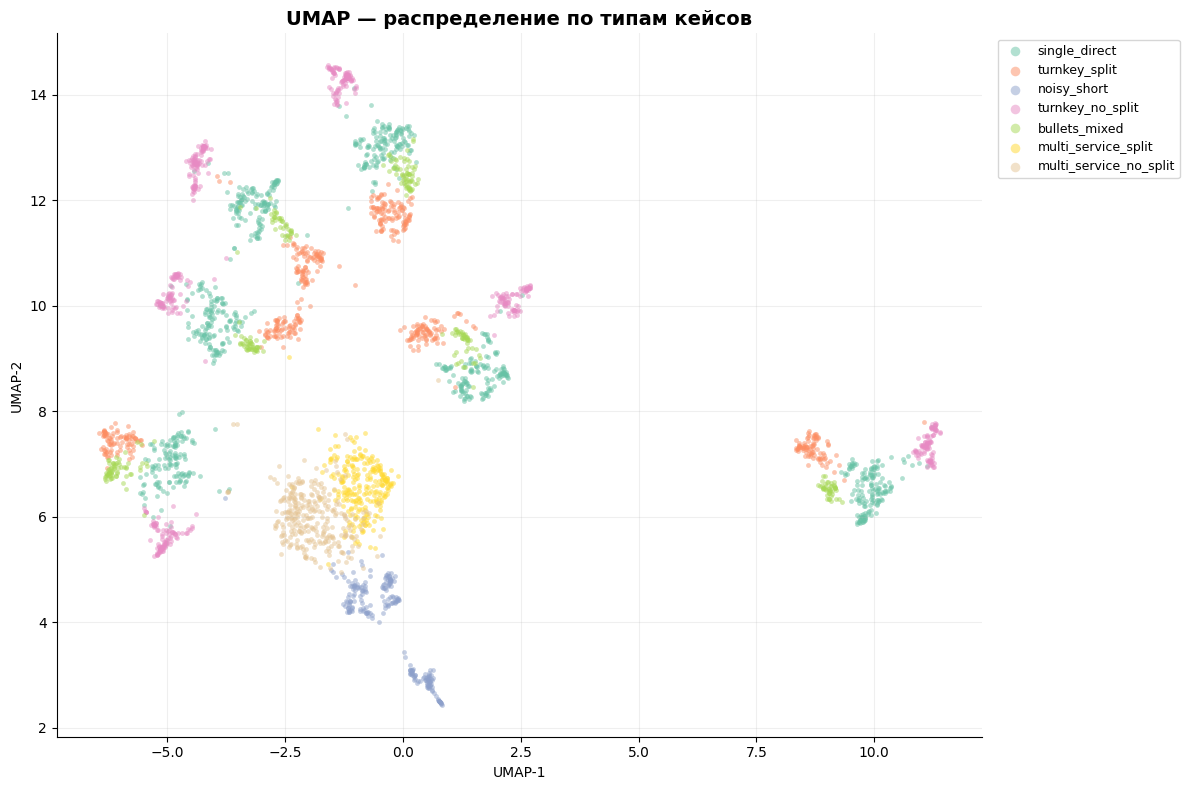

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))
case_types = df["caseType"].unique()
palette = sns.color_palette("Set2", len(case_types))
for i, ct in enumerate(case_types):
    mask = df["caseType"] == ct
    ax.scatter(df["umap_x"][mask], df["umap_y"][mask],
               c=[palette[i]], label=ct, alpha=0.5, s=12, linewidths=0)
ax.set_title("UMAP — распределение по типам кейсов", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, markerscale=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.grid(True, alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

In [19]:
score = silhouette_score(embeddings, labels_mc, metric="cosine", sample_size=1000, random_state=42)
print(f"Silhouette Score (по sourceMcTitle, cosine): {score:.4f}")

Silhouette Score (по sourceMcTitle, cosine): 0.0643


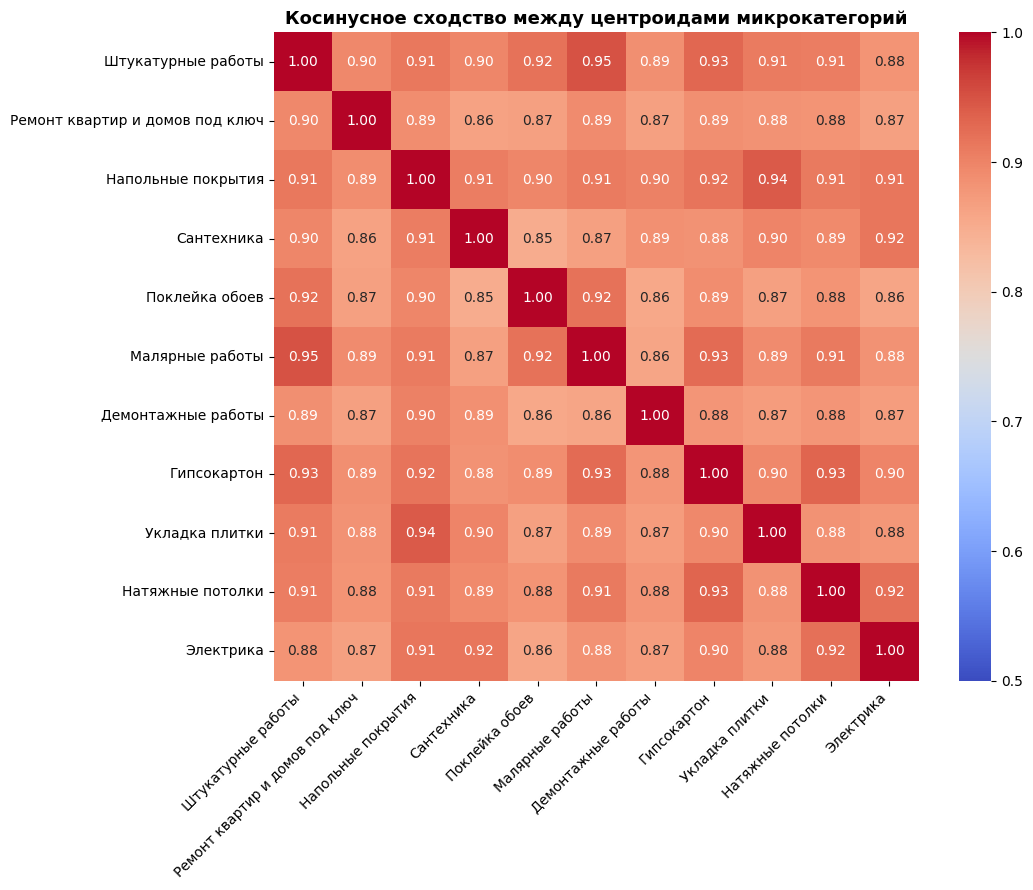

In [20]:
mc_titles = df["sourceMcTitle"].unique()
centroids = np.array([embeddings[df["sourceMcTitle"] == mc].mean(axis=0) for mc in mc_titles])
norms = np.linalg.norm(centroids, axis=1, keepdims=True)
centroids_normed = centroids / norms
cosine_sim_matrix = centroids_normed @ centroids_normed.T

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cosine_sim_matrix, xticklabels=mc_titles, yticklabels=mc_titles,
            cmap="coolwarm", annot=True, fmt=".2f", ax=ax, vmin=0.5, vmax=1.0)
ax.set_title("Косинусное сходство между центроидами микрокатегорий", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

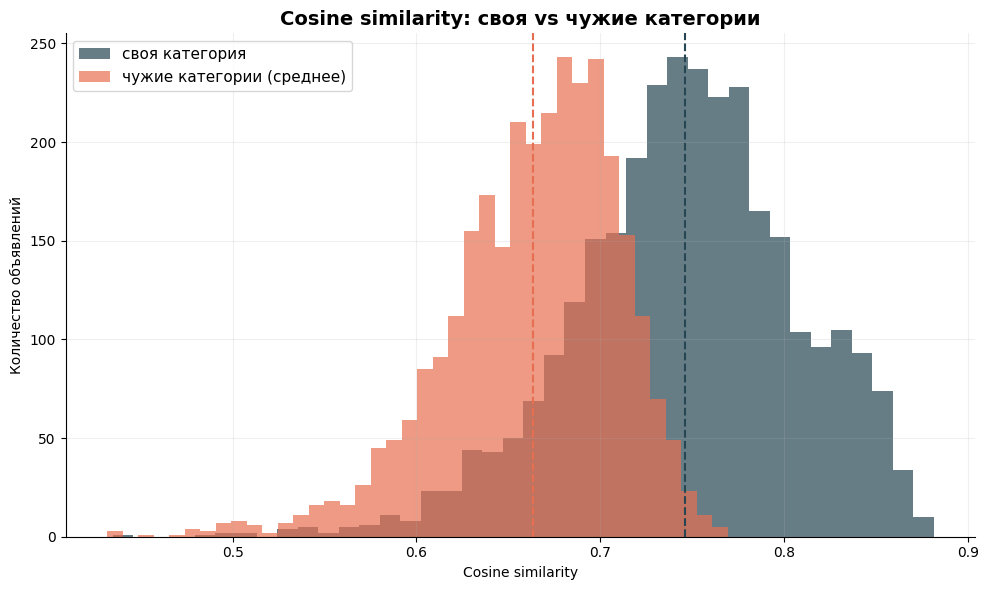

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

same_sim, diff_sim = [], []
for i, row in df.iterrows():
    emb = embeddings[df.index.get_loc(i)].reshape(1, -1)
    same_mc = row["sourceMcTitle"]
    same_centroid = centroids[list(mc_titles).index(same_mc)].reshape(1, -1)
    diff_centroids = centroids[[j for j, mc in enumerate(mc_titles) if mc != same_mc]]
    same_sim.append(cosine_similarity(emb, same_centroid)[0][0])
    diff_sim.append(cosine_similarity(emb, diff_centroids).mean())

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(same_sim, bins=40, alpha=0.7, color="#264653", label="своя категория")
ax.hist(diff_sim, bins=40, alpha=0.7, color="#e76f51", label="чужие категории (среднее)")
ax.axvline(np.mean(same_sim), color="#264653", linestyle="--", linewidth=1.5)
ax.axvline(np.mean(diff_sim), color="#e76f51", linestyle="--", linewidth=1.5)
ax.set_title("Cosine similarity: своя vs чужие категории", fontsize=14, fontweight="bold")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Количество объявлений")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

# Фичи:


## Классификатор shouldSplit:
Текстовые:
- description_word_count
- description_char_count
- split_marker_count        # "отдельно", "также выполняем", "помимо"
- complex_marker_count      # "под ключ", "включая", "в том числе"
- marker_ratio              # split / (complex + 1)
- has_bullets               # есть ли список/перечисление в тексте

Категориальные:
- source_mc_id              # as category
- is_turnkey                # source == "Ремонт квартир и домов под ключ"

Эмбеддинговые:
- embedding (312-dim)       # mini FRIDA, главный сигнал по кластерам

## Детекция микрокатегорий:
- cosine_similarity(chunk_embedding, keyphrase_embeddings)  # bi-encoder
- rapidfuzz_match_score(description, keyPhrases)            # предфильтр
- nli_entailment_score(description, "селлер предлагает X отдельно")
- split_marker_near_keyphrase                               # "отдельно" в окне ±2 предложения от упоминания категории

## shouldSplit: train + inference

Ниже короткий рабочий блок для:
1. обучения `shouldSplit` модели через существующий pipeline,
2. сохранения артефакта,
3. инференса по новым объявлениям из артефакта.

In [ ]:
from pathlib import Path

import pandas as pd

from avito.classifier import train_should_split_models
from avito.config import AvitoCaseConfig
from avito.features import ShouldSplitFeatureConfig
from avito.inference import predict_should_split_from_artifact


case_config = AvitoCaseConfig.from_default_yaml()
feature_config = ShouldSplitFeatureConfig(
    include_extra_text_features=case_config.should_split.include_extra_text_features,
)

data_path = Path("avito/data/rnc_dataset.csv")
artifact_path = Path("checkpoints/avito_should_split_model.joblib")

train_df = pd.read_csv(data_path)
result = train_should_split_models(
    df=train_df,
    include_embeddings=False,
    feature_config=feature_config,
    training_config=case_config.should_split.training,
)

artifact_path.parent.mkdir(parents=True, exist_ok=True)
payload = {
    "best_model_name": result.model_name,
    "pipeline": result.pipeline,
    "with_embeddings": False,
    "feature_config": feature_config.model_dump(mode="json"),
}

import joblib
joblib.dump(payload, artifact_path)

sample_df = train_df.iloc[:5][["description", "sourceMcId", "sourceMcTitle"]].copy()
inference = predict_should_split_from_artifact(
    df=sample_df,
    artifact_path=artifact_path,
)

sample_df["shouldSplit_pred"] = inference.predictions
sample_df["shouldSplit_proba"] = inference.probabilities
sample_df.head()